# Assignment 9 - Assignment
## Topic: Decision Tree

### Question 1
Load the Heart Attack dataset from the CSV file. Display the first 10 rows and identify the input features and target variable.

Dataset: [figshare.com](https://figshare.com/articles/dataset/heart_csv/20236848?file=36169122)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv('Assignment_9b.csv')

print('Dataset Shape:', df.shape)
print('\nFirst 10 Rows:')
print(df.head(10))
# Identify features and target
print('INPUT FEATURES (X):')
print('='*50)
feature_descriptions = {
    'age':      'Age of the patient (years)',
    'sex':      'Sex (1 = male, 0 = female)',
    'cp':       'Chest pain type (0-3)',
    'trtbps':   'Resting blood pressure (mm Hg)',
    'chol':     'Serum cholesterol (mg/dl)',
    'fbs':      'Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)',
    'restecg':  'Resting ECG results (0-2)',
    'thalachh': 'Maximum heart rate achieved',
    'exng':     'Exercise-induced angina (1 = yes, 0 = no)',
    'oldpeak':  'ST depression induced by exercise relative to rest',
    'slp':      'Slope of peak exercise ST segment',
    'caa':      'Number of major vessels (0-4) colored by fluoroscopy',
    'thall':    'Thalassemia (0-3)'
}
for col, desc in feature_descriptions.items():
    print(f'  {col:10s}: {desc}')

print('\nTARGET VARIABLE (y):')
print('='*50)
print('  output: Heart attack likelihood (1 = more likely, 0 = less likely)')
print('\nClass Distribution:')
print(df['output'].value_counts())
print(f'\nTotal samples: {len(df)}')
# Basic dataset info
print('Dataset Info:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())
print('\nBasic Statistics:')
df.describe().round(2)

Dataset Shape: (289, 14)

First 10 Rows:
   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   60    1   3     145   233    1        0       150     0      2.3    0   
1   35    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   55    1   1     120   236    0        1       178     0      0.8    2   
4   56    0   0     120   354    0        1       163     1      0.6    2   
5   55    1   0     140   192    0        1       148     0      0.4    1   
6   56    0   1     140   294    0        0       153     0      1.3    1   
7   44    1   1     120   263    0        1       173     0      0.0    2   
8   52    1   2     172   199    1        1       162     0      0.5    2   
9   57    1   2     150   168    0        1       174     0      1.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2  

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,289.00,289.00,289.00,289.00,289.00,289.00,289.00,289.00,289.00,289.00,289.00,289.00,289.00,289.00
mean,54.01,0.68,1.02,131.38,247.96,0.15,0.52,150.23,0.32,1.01,1.42,0.71,2.31,0.57
std,9.13,0.47,1.03,17.52,51.60,0.35,0.51,22.90,0.47,1.13,0.61,1.02,0.60,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.00,0.00,0.00,120.00,212.00,0.00,0.00,136.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,54.00,1.00,1.00,130.00,243.00,0.00,1.00,154.00,0.00,0.60,1.00,0.00,2.00,1.00
75%,60.00,1.00,2.00,140.00,276.00,0.00,1.00,168.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


### Question 2
Create scatter plots for at least two pairs of features (e.g., Age vs Cholesterol, Age vs Maximum Heart Rate) to visualize class separability. Use different colors for each class.

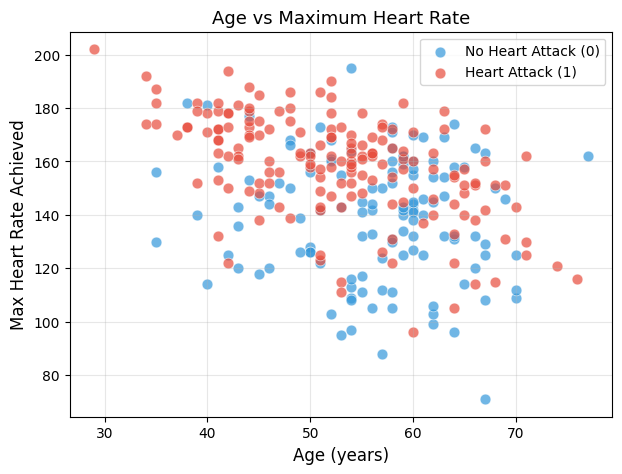

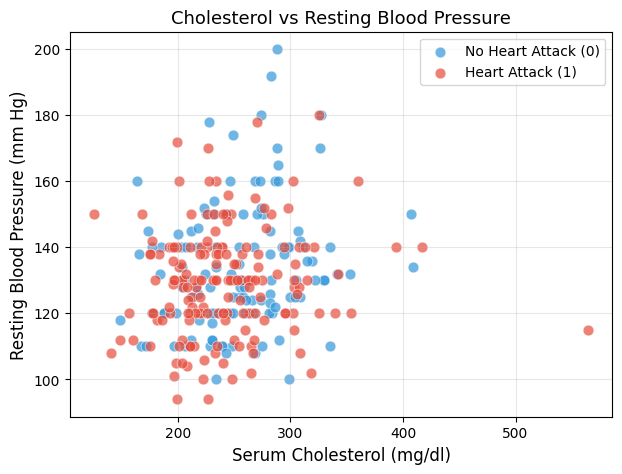

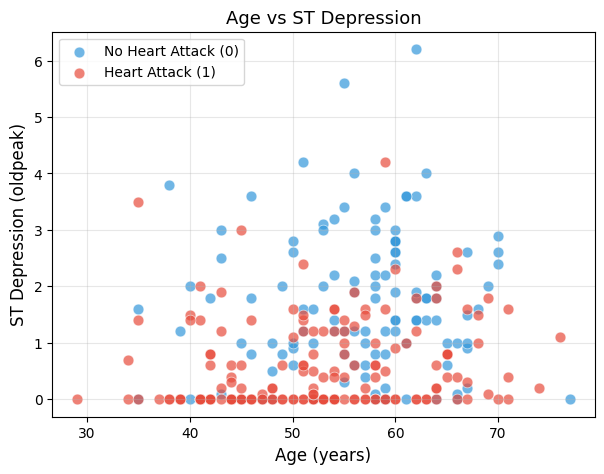

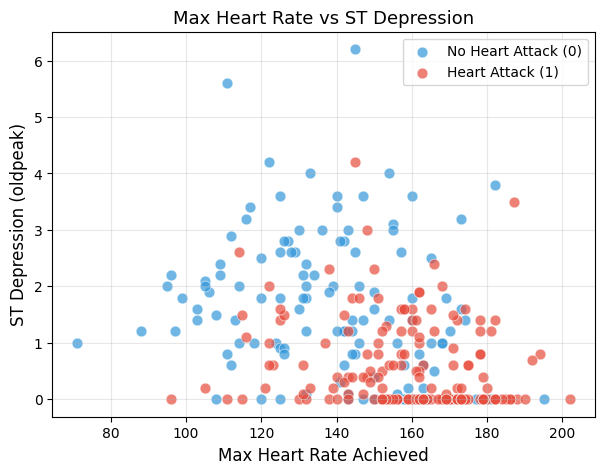

All scatter plots saved at 1200 DPI


In [2]:
# Color mapping for classes
colors = {1: '#e74c3c', 0: '#3498db'}
labels = {1: 'Heart Attack (1)', 0: 'No Heart Attack (0)'}

# -------- Plot 1: Age vs Max Heart Rate --------
plt.figure(figsize=(7,5))
for cls in [0,1]:
    subset = df[df['output'] == cls]
    plt.scatter(subset['age'], subset['thalachh'],
                c=colors[cls],
                label=labels[cls],
                alpha=0.7,
                edgecolors='white',
                linewidth=0.5,
                s=60)
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Max Heart Rate Achieved', fontsize=12)
plt.title('Age vs Maximum Heart Rate', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('Assignment_9b_scatter_age_vs_hr.png', dpi=1200, bbox_inches='tight')
plt.show()
# -------- Plot 2: Cholesterol vs Resting Blood Pressure --------
plt.figure(figsize=(7,5))

for cls in [0,1]:
    subset = df[df['output'] == cls]
    plt.scatter(subset['chol'], subset['trtbps'],
                c=colors[cls],
                label=labels[cls],
                alpha=0.7,
                edgecolors='white',
                linewidth=0.5,
                s=60)

plt.xlabel('Serum Cholesterol (mg/dl)', fontsize=12)
plt.ylabel('Resting Blood Pressure (mm Hg)', fontsize=12)
plt.title('Cholesterol vs Resting Blood Pressure', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('Assignment_9b_scatter_chol_vs_bp.png', dpi=1200, bbox_inches='tight')
plt.show()



# -------- Plot 3: Age vs ST Depression --------
plt.figure(figsize=(7,5))

for cls in [0,1]:
    subset = df[df['output'] == cls]
    plt.scatter(subset['age'], subset['oldpeak'],
                c=colors[cls],
                label=labels[cls],
                alpha=0.7,
                edgecolors='white',
                linewidth=0.5,
                s=60)

plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('ST Depression (oldpeak)', fontsize=12)
plt.title('Age vs ST Depression', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('Assignment_9b_scatter_age_vs_oldpeak.png', dpi=1200, bbox_inches='tight')
plt.show()



# -------- Plot 4: Max Heart Rate vs ST Depression --------
plt.figure(figsize=(7,5))

for cls in [0,1]:
    subset = df[df['output'] == cls]
    plt.scatter(subset['thalachh'], subset['oldpeak'],
                c=colors[cls],
                label=labels[cls],
                alpha=0.7,
                edgecolors='white',
                linewidth=0.5,
                s=60)

plt.xlabel('Max Heart Rate Achieved', fontsize=12)
plt.ylabel('ST Depression (oldpeak)', fontsize=12)
plt.title('Max Heart Rate vs ST Depression', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('Assignment_9b_scatter_hr_vs_oldpeak.png', dpi=1200, bbox_inches='tight')
plt.show()


print("All scatter plots saved at 1200 DPI")

### Question 3
Build a Decision Tree classifier using sklearn.tree.DecisionTreeClassifier. Train the model and print the predicted classes for the test set.

In [3]:
# Prepare features and target
X = df.drop('output', axis=1)
y = df['output']

feature_names = X.columns.tolist()
print('Features used for training:', feature_names)
print('Target variable: output')

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTraining samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')
# Build and train the Decision Tree
dt_classifier = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

dt_classifier.fit(X_train, y_train)
print('Decision Tree trained successfully!')
print(f'Tree Depth: {dt_classifier.get_depth()}')
print(f'Number of Leaves: {dt_classifier.get_n_leaves()}')
print(f'Number of Features: {dt_classifier.n_features_in_}')
# Predict and display results
y_pred = dt_classifier.predict(X_test)

print('Predicted Classes for Test Set:')
print('='*60)
results_df = pd.DataFrame({
    'Actual':    y_test.values,
    'Predicted': y_pred,
    'Correct':   (y_test.values == y_pred)
})
print(results_df.to_string(index=False))

print(f'\nTotal Test Samples : {len(y_test)}')
print(f'Correct Predictions: {results_df["Correct"].sum()}')
print(f'Wrong Predictions  : {(~results_df["Correct"]).sum()}')

Features used for training: ['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exng', 'oldpeak', 'slp', 'caa', 'thall']
Target variable: output

Training samples : 231
Testing samples  : 58
Decision Tree trained successfully!
Tree Depth: 4
Number of Leaves: 14
Number of Features: 13
Predicted Classes for Test Set:
 Actual  Predicted  Correct
      1          0    False
      0          0     True
      0          0     True
      0          1    False
      0          0     True
      0          1    False
      1          1     True
      0          0     True
      1          0    False
      0          0     True
      1          0    False
      1          0    False
      1          1     True
      1          1     True
      1          0    False
      1          1     True
      1          1     True
      1          0    False
      1          1     True
      1          1     True
      1          1     True
      0          0     True
      1          1   

### Question 4
Evaluate the Decision Tree classifier using accuracy, confusion matrix, and classification report.

Accuracy Score: 0.7241 (72.41%)

Confusion Matrix:
[[18  7]
 [ 9 24]]

  True Negatives  (TN): 18
  False Positives (FP): 7
  False Negatives (FN): 9
  True Positives  (TP): 24

Classification Report:
                     precision    recall  f1-score   support

No Heart Attack (0)       0.67      0.72      0.69        25
   Heart Attack (1)       0.77      0.73      0.75        33

           accuracy                           0.72        58
          macro avg       0.72      0.72      0.72        58
       weighted avg       0.73      0.72      0.73        58



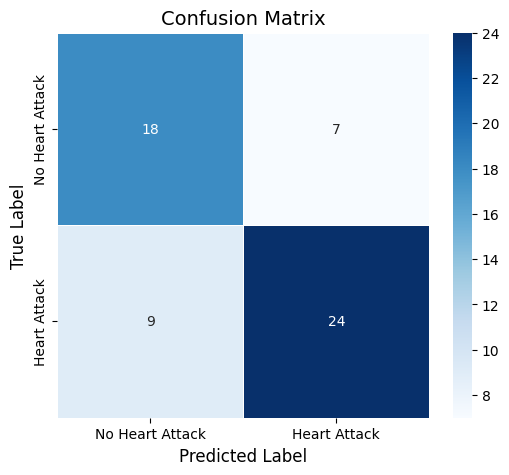

Confusion matrix saved as Assignment_9b_confusion_matrix.png


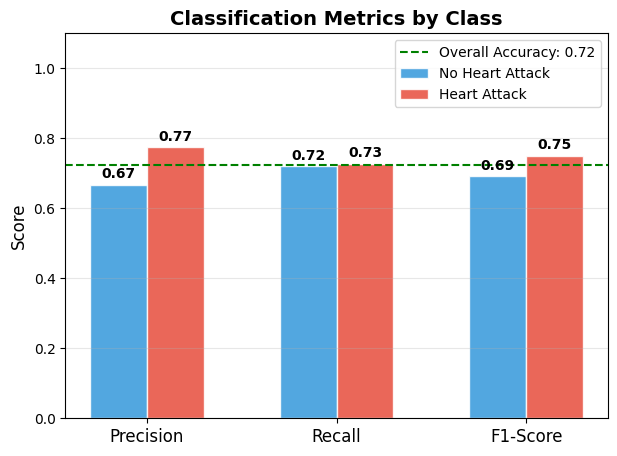

In [4]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)')
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix:')
print(cm)
tn, fp, fn, tp = cm.ravel()
print(f'\n  True Negatives  (TN): {tn}')
print(f'  False Positives (FP): {fp}')
print(f'  False Negatives (FN): {fn}')
print(f'  True Positives  (TP): {tp}')

# Classification Report
print('\nClassification Report:')
print('='*55)
print(classification_report(y_test, y_pred, 
                             target_names=['No Heart Attack (0)', 'Heart Attack (1)']))
# -------- Confusion Matrix --------
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Heart Attack', 'Heart Attack'],
    yticklabels=['No Heart Attack', 'Heart Attack'],
    linewidths=0.5,
    linecolor='white'
)

plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

plt.savefig('Assignment_9b_confusion_matrix.png', dpi=1200, bbox_inches='tight')
plt.show()

print("Confusion matrix saved as Assignment_9b_confusion_matrix.png")

# -------- Classification Metrics Bar Chart --------
plt.figure(figsize=(7,5))

report = classification_report(
    y_test,
    y_pred,
    target_names=['No Heart Attack', 'Heart Attack'],
    output_dict=True
)

metrics = ['precision', 'recall', 'f1-score']
classes = ['No Heart Attack', 'Heart Attack']

x = np.arange(len(metrics))
width = 0.3
colors_bar = ['#3498db', '#e74c3c']

for i, (cls, color) in enumerate(zip(classes, colors_bar)):
    vals = [report[cls][m] for m in metrics]

    bars = plt.bar(
        x + i * width,
        vals,
        width,
        label=cls,
        color=color,
        alpha=0.85,
        edgecolor='white'
    )

    for bar, val in zip(bars, vals):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.2f}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )
accuracy = accuracy_score(y_test, y_pred)
plt.axhline(
    y=accuracy,
    color='green',
    linestyle='--',
    linewidth=1.5,
    label=f'Overall Accuracy: {accuracy:.2f}'
)

plt.xticks(x + width/2, ['Precision', 'Recall', 'F1-Score'], fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1.1)
plt.title('Classification Metrics by Class', fontsize=14, fontweight='bold')

plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')

plt.savefig('Assignment_9b_classification_metrics.png', dpi=1200, bbox_inches='tight')
plt.show()

### Question 5
Visualize the trained decision tree using plot_tree and export it as text.

Decision Tree (Text Representation):
|--- thall <= 2.50
|   |--- caa <= 0.50
|   |   |--- trtbps <= 158.00
|   |   |   |--- chol <= 311.50
|   |   |   |   |--- class: 1
|   |   |   |--- chol >  311.50
|   |   |   |   |--- class: 1
|   |   |--- trtbps >  158.00
|   |   |   |--- class: 0
|   |--- caa >  0.50
|   |   |--- oldpeak <= 0.55
|   |   |   |--- cp <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- cp >  1.50
|   |   |   |   |--- class: 1
|   |   |--- oldpeak >  0.55
|   |   |   |--- sex <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- sex >  0.50
|   |   |   |   |--- class: 0
|--- thall >  2.50
|   |--- oldpeak <= 0.70
|   |   |--- restecg <= 0.50
|   |   |   |--- age <= 55.00
|   |   |   |   |--- class: 0
|   |   |   |--- age >  55.00
|   |   |   |   |--- class: 1
|   |   |--- restecg >  0.50
|   |   |   |--- thalachh <= 158.50
|   |   |   |   |--- class: 1
|   |   |   |--- thalachh >  158.50
|   |   |   |   |--- class: 1
|   |--- oldpeak >  0.70
|   |   |--- cp <= 2.

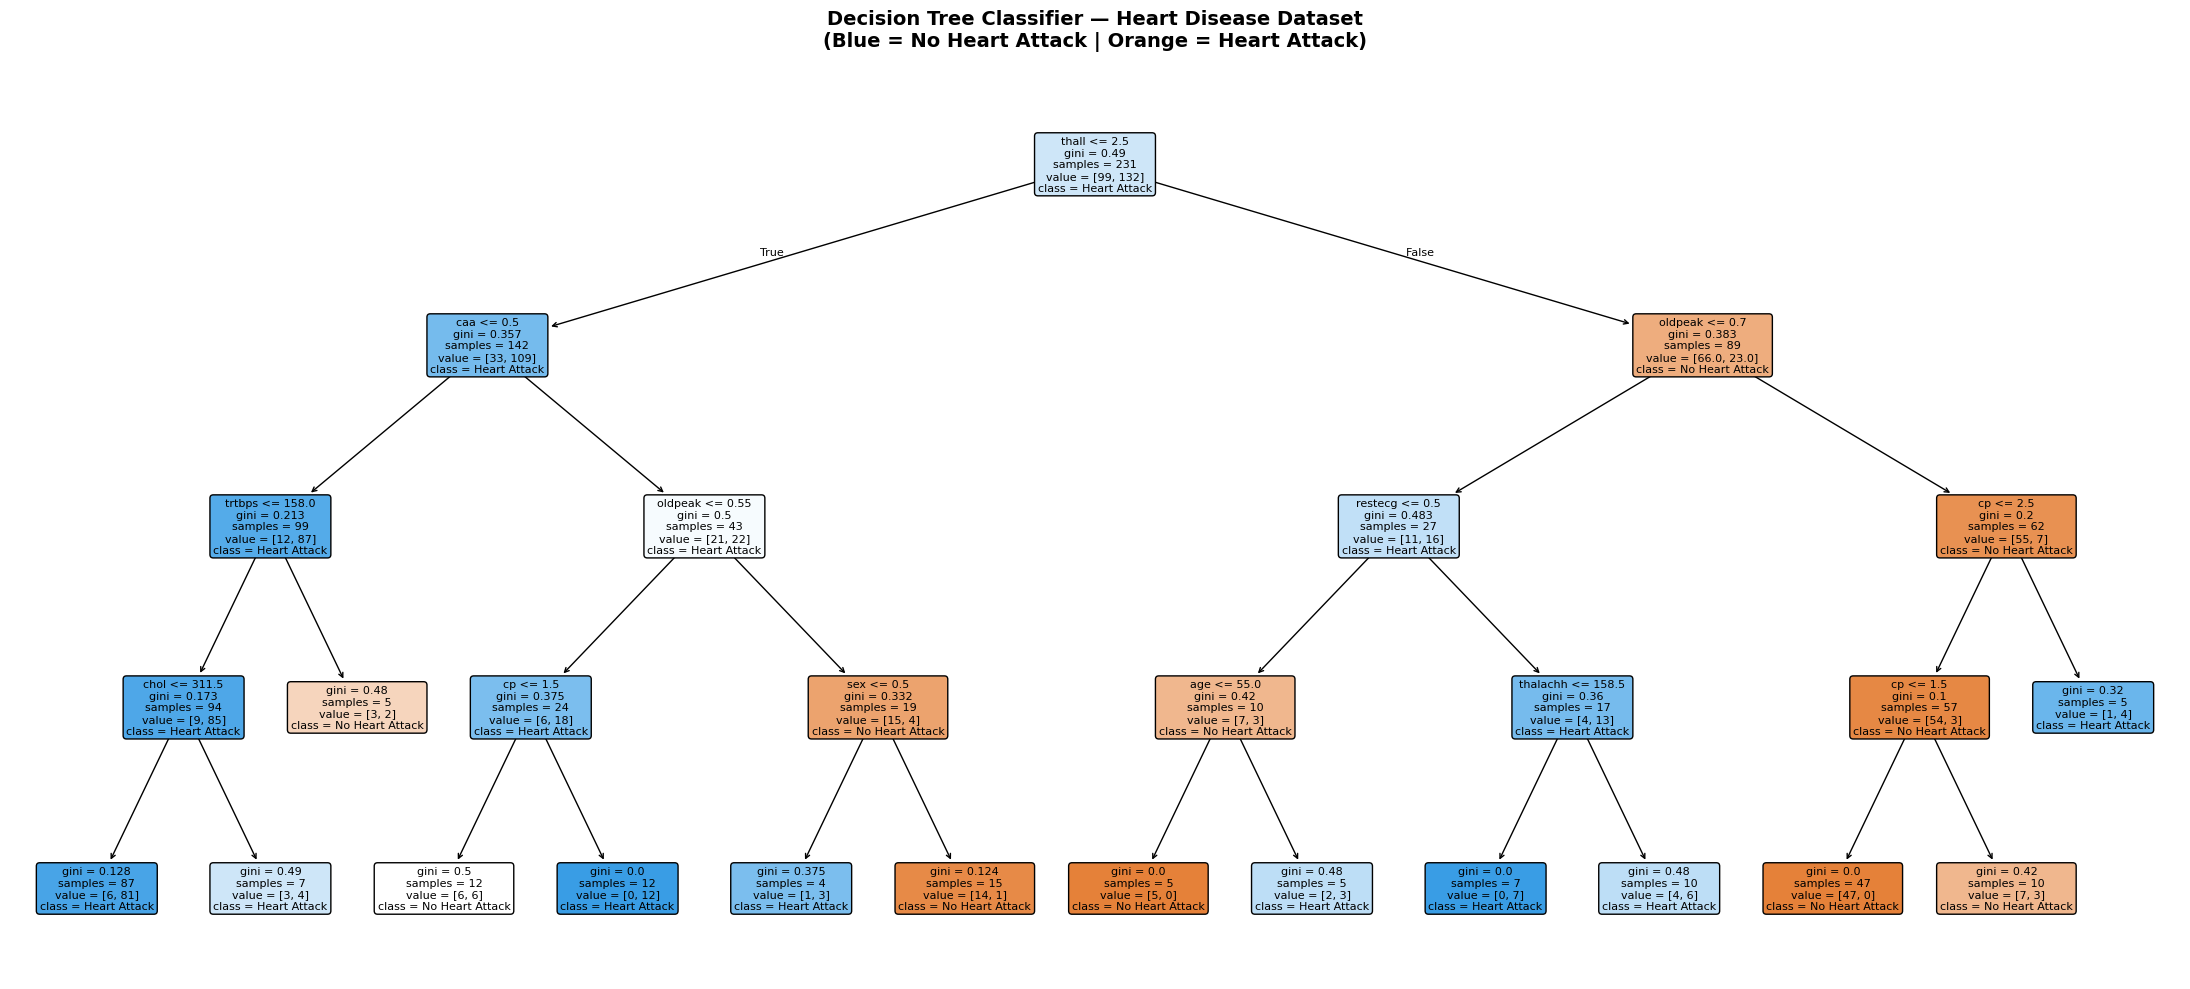

Decision tree visualization saved as Assignment_9b_decision_tree_visual.png


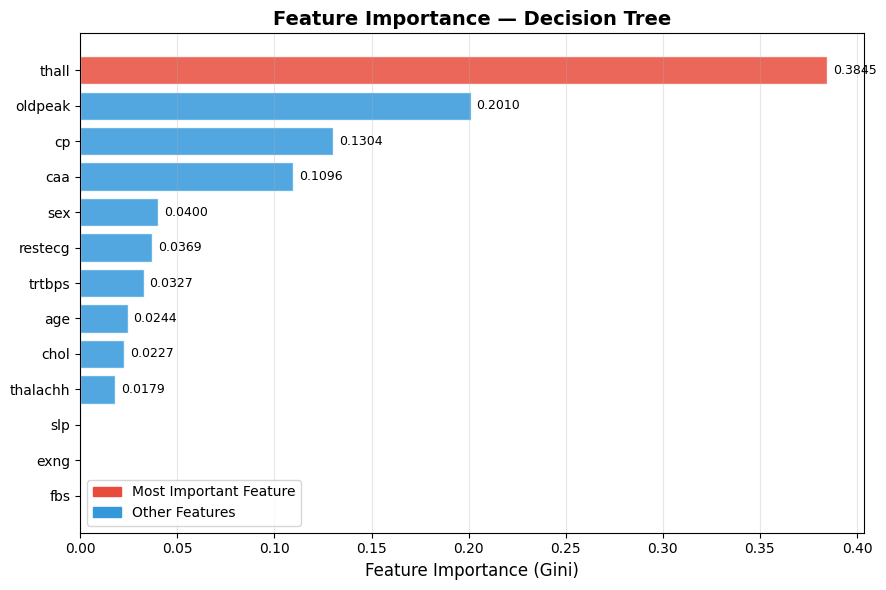

Feature importance chart saved as Assignment_9b_feature_importance.png

Top 5 Most Important Features:
thall      0.384527
oldpeak    0.200996
cp         0.130387
caa        0.109558
sex        0.039974
dtype: float64


In [5]:
print('Decision Tree (Text Representation):')
print('='*60)
tree_text = export_text(dt_classifier, feature_names=feature_names)
print(tree_text)
# --- Visual Decision Tree Plot ---
fig, ax = plt.subplots(figsize=(22, 10))

plot_tree(
    dt_classifier,
    feature_names=feature_names,
    class_names=['No Heart Attack', 'Heart Attack'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=True,
    proportion=False
)

ax.set_title('Decision Tree Classifier — Heart Disease Dataset\n'
             '(Blue = No Heart Attack | Orange = Heart Attack)',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('Assignment_9b_decision_tree_visual.png', dpi=1200, bbox_inches='tight')
plt.show()
print('Decision tree visualization saved as Assignment_9b_decision_tree_visual.png')
# Feature Importance
importances = dt_classifier.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_imp = ['#e74c3c' if v == feat_imp.max() else '#3498db' for v in feat_imp.values]
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors_imp, edgecolor='white', alpha=0.85)

for bar, val in zip(bars, feat_imp.values):
    if val > 0:
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Feature Importance — Decision Tree', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

red_patch = mpatches.Patch(color='#e74c3c', label='Most Important Feature')
blue_patch = mpatches.Patch(color='#3498db', label='Other Features')
ax.legend(handles=[red_patch, blue_patch], fontsize=10)

plt.tight_layout()
plt.savefig('Assignment_9b_feature_importance.png', dpi=1200, bbox_inches='tight')
plt.show()
print('Feature importance chart saved as Assignment_9b_feature_importance.png')

print('\nTop 5 Most Important Features:')
print(feat_imp.sort_values(ascending=False).head())

### Question 6
Predict the heart attack risk for a new patient with the following features: age=52, sex=1 (male), cp=0 (typical angina), trtbps=125, chol=212, fbs=0, restecg=1, thalachh=168, exng=0, oldpeak=1.0, slp=2, caa=2, thall=3

In [6]:
print('----- New Patient Prediction -----')

# New patient features
new_patient = pd.DataFrame([{
    'age': 52, 'sex': 1, 'cp': 0, 'trtbps': 125, 'chol': 212,
    'fbs': 0, 'restecg': 1, 'thalachh': 168, 'exng': 0,
    'oldpeak': 1.0, 'slp': 2, 'caa': 2, 'thall': 3
}])

print('\nInput Features:')
print('  age=52, sex=1 (male), cp=0 (typical angina), trtbps=125, chol=212,')
print('  fbs=0, restecg=1, thalachh=168, exng=0, oldpeak=1.0,')
print('  slp=2, caa=2, thall=3')

# Predict
pred_class = dt_classifier.predict(new_patient)[0]
pred_prob = dt_classifier.predict_proba(new_patient)[0]

outcome_map = {0: 'Less chance of heart attack', 1: 'More chance of heart attack'}
print(f'\nPredicted Class: {pred_class} ({outcome_map[pred_class]})')
print('\nPrediction Probabilities:')
print(f'  Less chance (0):  {pred_prob[0]:.2f}')
print(f'  More chance (1):  {pred_prob[1]:.2f}')
print(f'\nResult: {outcome_map[pred_class].upper()}')

----- New Patient Prediction -----

Input Features:
  age=52, sex=1 (male), cp=0 (typical angina), trtbps=125, chol=212,
  fbs=0, restecg=1, thalachh=168, exng=0, oldpeak=1.0,
  slp=2, caa=2, thall=3

Predicted Class: 0 (Less chance of heart attack)

Prediction Probabilities:
  Less chance (0):  1.00
  More chance (1):  0.00

Result: LESS CHANCE OF HEART ATTACK
